In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/datasets/ayaanaraza/eyetracking/Images'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages/TS176_03.png
/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages/TS110_19.png
/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages/TS085_19.png
/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages/TS064_19.png
/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages/TS008_20.png
/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages/TS188_05.png
/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages/TS088_18.png
/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages/TS170_24.png
/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages/TS066_19.png
/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages/TS070_18.png
/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages/TS007_20.png
/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages/TS173_24.png
/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages/TS054_11.png
/kaggle/input/datasets/ay

In [ ]:

import os
import glob
import numpy as np
import cv2
#from keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.decomposition import PCA

In [7]:
img_dim = 100
aug_img_count = 3
cropped_dir_tc= '/kaggle/working/Dataset/TC/Cropped'
cropped_dir_ts = '/kaggle/working/Dataset/TS/Cropped'
aug_tc_dir = '/kaggle/working/Dataset/TC/Augmented'
aug_ts_dir = '/kaggle/working/Dataset/TS/Augmented'
output_npz = '/kaggle/working/ASD_combined.npz'
os.makedirs(cropped_dir_tc, exist_ok=True)
os.makedirs(cropped_dir_ts, exist_ok=True)
os.makedirs(aug_tc_dir, exist_ok=True)
os.makedirs(aug_ts_dir, exist_ok=True)

Starting full dataset augmentation...

 Category: TC | Original images: 328
 Augmented 984 images saved to: /kaggle/working/Dataset/TC/Augmented

 Category: TS | Original images: 219
 Augmented 657 images saved to: /kaggle/working/Dataset/TS/Augmented

 Displaying 1 original + 2 augmented samples per category...


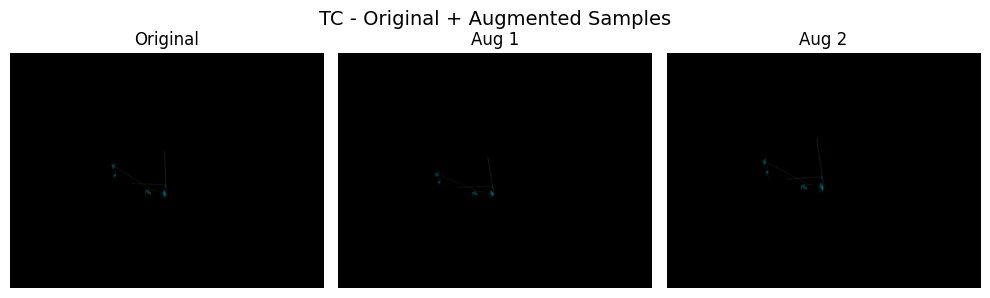

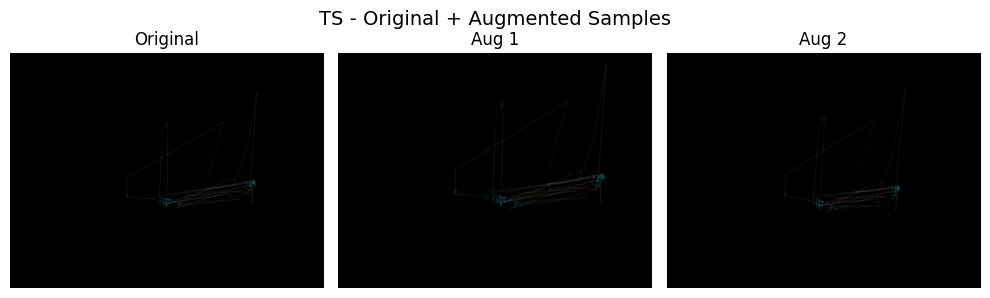

In [8]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

# ============ STEP 1: IMAGE AUGMENTATION ============
print("Starting full dataset augmentation...")

# Setup augmenter
augmenter = ImageDataGenerator(rotation_range=10, shear_range=0.2, zoom_range=0.2, fill_mode='nearest')

# Define original and augmented image directories
categories = {
    'TC': '/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TCImages',
    'TS': '/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages'
}

# Update with your actual output folders for augmented images
aug_tc_dir = '/kaggle/working/Dataset/TC/Augmented'
aug_ts_dir = '/kaggle/working/Dataset/TS/Augmented'
os.makedirs(aug_tc_dir, exist_ok=True)
os.makedirs(aug_ts_dir, exist_ok=True)

# Number of augmented images to generate per original image
aug_img_count = 3

# Augment and save for all images
for category, folder in categories.items():
    save_dir = aug_tc_dir if category == 'TC' else aug_ts_dir
    image_paths = glob.glob(os.path.join(folder, '*.png'))
    print(f"\n Category: {category} | Original images: {len(image_paths)}")

    for file in image_paths:
        img = load_img(file)
        img_array = img_to_array(img)
        img_array = img_array.reshape((1,) + img_array.shape)
        base_name = os.path.splitext(os.path.basename(file))[0]
        count = 0
        for batch in augmenter.flow(img_array, batch_size=1, save_to_dir=save_dir,
                                   save_prefix=base_name + '_aug', save_format='png'):
            count += 1
            # Save the augmented images with the number appended
            if count == aug_img_count:
                break

    print(f" Augmented {aug_img_count * len(image_paths)} images saved to: {save_dir}")

# ============ STEP 2: SHOW ONE ORIGINAL + TWO AUGMENTED SAMPLES ============
print("\n Displaying 1 original + 2 augmented samples per category...")

preview_aug_count = 2  # Number of augmentations to preview

for category, folder in categories.items():
    image_paths = glob.glob(os.path.join(categories[category], '*.png'))
    if not image_paths:
        continue

    # Pick the first image
    img_path = image_paths[0]
    img = load_img(img_path)
    img_array = img_to_array(img).astype('uint8')
    img_array = img_array.reshape((1,) + img_array.shape)

    plt.figure(figsize=(10, 3))
    plt.subplot(1, preview_aug_count + 1, 1)
    plt.imshow(img_array[0].astype('uint8') / 255.0)
    plt.title("Original")
    plt.axis("off")

    for i, batch in enumerate(augmenter.flow(img_array, batch_size=1)):
        aug_img = batch[0].astype('uint8')
        # Add the augmentation number to the title
        plt.subplot(1, preview_aug_count + 1, i + 2)
        plt.imshow(aug_img / 255.0)
        plt.title(f'Aug {i+1}')
        plt.axis('off')
        if i + 1 == preview_aug_count:
            break

    plt.suptitle(f"{category} - Original + Augmented Samples", fontsize=14)
    plt.tight_layout()
    plt.show()


In [6]:
aug_tc_images = glob.glob('/kaggle/working/Dataset/TC/Augmented/*.png')
aug_ts_images = glob.glob('/kaggle/working/Dataset/TS/Augmented/*.png')
print(f"TC Augmented: {len(aug_tc_images)} | TS: {len(aug_ts_images)}")

TC Augmented: 0 | TS: 0


In [ ]:
aug_tc_images = glob.glob('/kaggle/working/Dataset/TC/Augmented/*.[Pp][Nn][Gg]')
aug_ts_images = glob.glob('/kaggle/working/Dataset/TS/Augmented/*.[Pp][Nn][Gg]')
print(f"TC Augmented: {len(aug_tc_images)} | TS: {len(aug_ts_images)}")

print("First 5 TC Augmented Images:", aug_tc_images[:5])
print("First 5 TS Augmented Images:", aug_ts_images[:5])


TC Augmented: 984 | TS: 657
First 5 TC Augmented Images: ['/kaggle/working/Dataset/TC/Augmented/TC055_30_aug_0_6063.png', '/kaggle/working/Dataset/TC/Augmented/TC037_31_aug_0_780.png', '/kaggle/working/Dataset/TC/Augmented/TC347_58_aug_0_5670.png', '/kaggle/working/Dataset/TC/Augmented/TC096_54_aug_0_560.png', '/kaggle/working/Dataset/TC/Augmented/TC273_56_aug_0_2973.png']
First 5 TS Augmented Images: ['/kaggle/working/Dataset/TS/Augmented/TS196_10_aug_0_1704.png', '/kaggle/working/Dataset/TS/Augmented/TS087_15_aug_0_6807.png', '/kaggle/working/Dataset/TS/Augmented/TS013_15_aug_0_8916.png', '/kaggle/working/Dataset/TS/Augmented/TS053_07_aug_0_6516.png', '/kaggle/working/Dataset/TS/Augmented/TS217_06_aug_0_8607.png']


 Cropping augmented images and previewing...


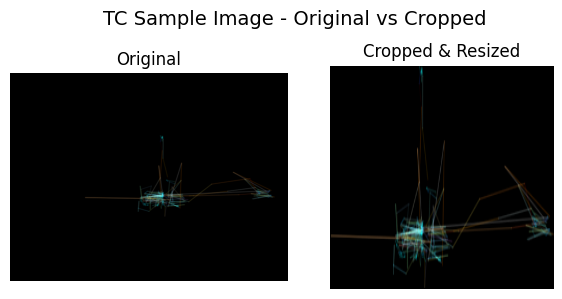

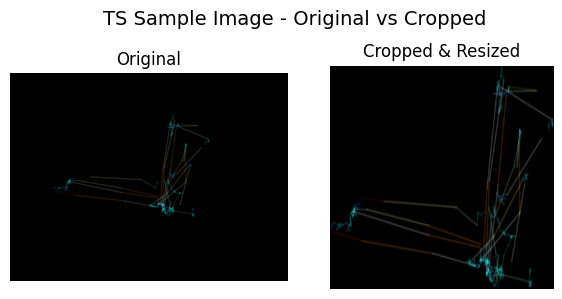


 Total Cropped Images:
   TC: 984
   TS: 657


In [ ]:
import os
import glob
import cv2
import matplotlib.pyplot as plt

print(" Cropping augmented images and previewing...")

# Input folders
augmented_folders = [
    '/kaggle/working/Dataset/TC/Augmented',
    '/kaggle/working/Dataset/TS/Augmented'
]

# Output folders
cropped_dir_tc = '/kaggle/working/Dataset/TC/Cropped'
cropped_dir_ts = '/kaggle/working/Dataset/TS/Cropped'
os.makedirs(cropped_dir_tc, exist_ok=True)
os.makedirs(cropped_dir_ts, exist_ok=True)

# Counters and preview flags
tc_count = 0
ts_count = 0
tc_preview_shown = False
ts_preview_shown = False

# Process images
for folder in augmented_folders:
    for img_file in glob.iglob(os.path.join(folder, '**/*.png'), recursive=True):
        img = cv2.imread(img_file)
        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        _, threshed = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(threshed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if contours:
            cnt = max(contours, key=cv2.contourArea)
            x, y, w, h = cv2.boundingRect(cnt)
            cropped = img[y:y + h, x:x + w]
            resized = cv2.resize(cropped, (224, 224))

            # Decide category
            if 'TC' in folder:
                target_dir = cropped_dir_tc
                tc_count += 1
                preview_flag = not tc_preview_shown
                tc_preview_shown = True
            else:
                target_dir = cropped_dir_ts
                ts_count += 1
                preview_flag = not ts_preview_shown
                ts_preview_shown = True

            # Save
            img_id = os.path.basename(img_file).rsplit('.', 1)[0]
            save_path = os.path.join(target_dir, img_id + '.jpg')
            cv2.imwrite(save_path, resized, [int(cv2.IMWRITE_JPEG_QUALITY), 100])

            # Show one preview image per category
            if preview_flag:
                plt.figure(figsize=(6, 3))
                plt.subplot(1, 2, 1)
                plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
                plt.title("Original")
                plt.axis("off")

                plt.subplot(1, 2, 2)
                plt.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
                plt.title("Cropped & Resized")
                plt.axis("off")

                cat = 'TC' if 'TC' in folder else 'TS'
                plt.suptitle(f"{cat} Sample Image - Original vs Cropped", fontsize=14)
                plt.tight_layout()
                plt.show()

# Print final counts
print(f"\n Total Cropped Images:")
print(f"   TC: {tc_count}")
print(f"   TS: {ts_count}")


In [ ]:
aug_tc_images = glob.glob('/kaggle/working/Dataset/TC/Augmented/*.png')
crop_tc_images = glob.glob('/kaggle/working/Dataset/TC/Cropped/*.jpg')

print(f"TC Augmented: {len(aug_tc_images)} | TC Cropped: {len(crop_tc_images)}")

aug_ts_images = glob.glob('/kaggle/working/Dataset/TS/Augmented/*.png')
crop_ts_images = glob.glob('/kaggle/working/Dataset/TS/Cropped/*.jpg')

print(f"TS Augmented: {len(aug_ts_images)} | TS Cropped: {len(crop_ts_images)}")

TC Augmented: 984 | TC Cropped: 984
TS Augmented: 657 | TS Cropped: 657


In [ ]:
import os
for dirname, _, filenames in os.walk('/kaggle/working'):
    if filenames:  # Only print folders that contain files
        print(dirname)

/kaggle/working/Dataset/TS/Augmented
/kaggle/working/Dataset/TS/Cropped
/kaggle/working/Dataset/TC/Augmented
/kaggle/working/Dataset/TC/Cropped


## DenseNet


In [ ]:
import numpy as np
import pandas as pd
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, AveragePooling2D,MaxPooling2D
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, recall_score
#from scipy import interp
import matplotlib.pyplot as plt
import time

In [ ]:
import os
import glob
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input  # EfficientNet-specific preprocessing
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Step 1: Feature Extraction with EfficientNetB0
print("🚀 Starting feature extraction using EfficientNetB0...")

# Load EfficientNetB0 base model
base_model = EfficientNetB0(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))
feature_extractor = Model(inputs=base_model.input, outputs=base_model.output)

# Define directories
cropped_dirs = {
    'TC': '/kaggle/working/Dataset/TC/Cropped',
    'TS': '/kaggle/working/Dataset/TS/Cropped'
}

features = []
labels = []

# Extract features from each image
for label, (cat, folder) in enumerate(cropped_dirs.items()):
    print(f"🔍 Extracting features for category: {cat}")
    image_paths = glob.glob(os.path.join(folder, '*.jpg'))

    for img_path in tqdm(image_paths):
        img = load_img(img_path, target_size=(224, 224))
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = preprocess_input(img_array)  # EfficientNet-specific preprocessing
        feature_vector = feature_extractor.predict(img_array, verbose=0)[0]
        features.append(feature_vector)
        labels.append(label)

# Convert to NumPy arrays
X = np.array(features)
y = np.array(labels)
print(f"✅ Feature extraction complete! X shape: {X.shape}, y shape: {y.shape}")

# Step 2: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)



🚀 Starting feature extraction using EfficientNetB0...
🔍 Extracting features for category: TC


  0%|          | 0/984 [00:00<?, ?it/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1745220176.127466      96 service.cc:148] XLA service 0x7dbca80022b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745220176.128263      96 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1745220176.823670      96 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1745220180.752858      96 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
100%|██████████| 984/984 [01:08<00:00, 14.33it/s]


🔍 Extracting features for category: TS


100%|██████████| 657/657 [00:39<00:00, 16.51it/s]

✅ Feature extraction complete! X shape: (1641, 1280), y shape: (1641,)



 Applying PCA to retain 99% variance...
Original shape: (1641, 1280)
Reduced shape: (1641, 444)
Number of features selected: 444


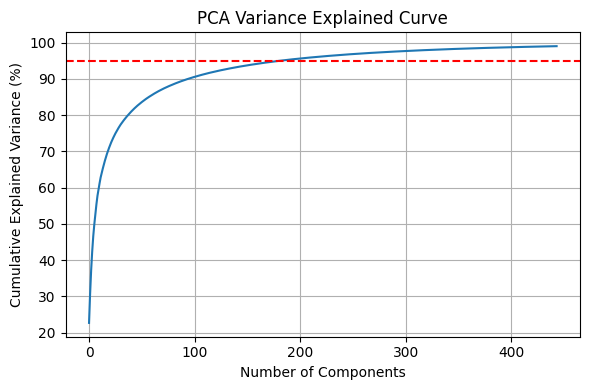

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Use PCA to retain 99% of the variance
print("\n Applying PCA to retain 99% variance...")

pca = PCA(n_components=0.99, random_state=42)
X_reduced = pca.fit_transform(X)

print(f"Original shape: {X.shape}")
print(f"Reduced shape: {X_reduced.shape}")
print(f"Number of features selected: {X_reduced.shape[1]}")

# Step 2 (optional): Plot cumulative explained variance
plt.figure(figsize=(6, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_) * 100)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('PCA Variance Explained Curve')
plt.grid(True)
plt.axhline(y=95, color='r', linestyle='--')
plt.tight_layout()
plt.show()


In [ ]:
# Step 2: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)



#No PCA DNN

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7051 - loss: 0.5752 - val_accuracy: 0.7872 - val_loss: 0.4791
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7603 - loss: 0.4820 - val_accuracy: 0.7660 - val_loss: 0.4650
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7616 - loss: 0.4668 - val_accuracy: 0.7903 - val_loss: 0.4535
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7581 - loss: 0.4655 - val_accuracy: 0.8176 - val_loss: 0.4185
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8105 - loss: 0.4019 - val_accuracy: 0.8207 - val_loss: 0.3953
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8179 - loss: 0.3866 - val_accuracy: 0.8359 - val_loss: 0.3897
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8087 - loss: 0.3931 - val_accuracy: 0.8055 - val_loss: 0.3793
Epoch 8/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8264 - loss: 0.3384 - val_accuracy: 0.8541 - val_loss: 0.

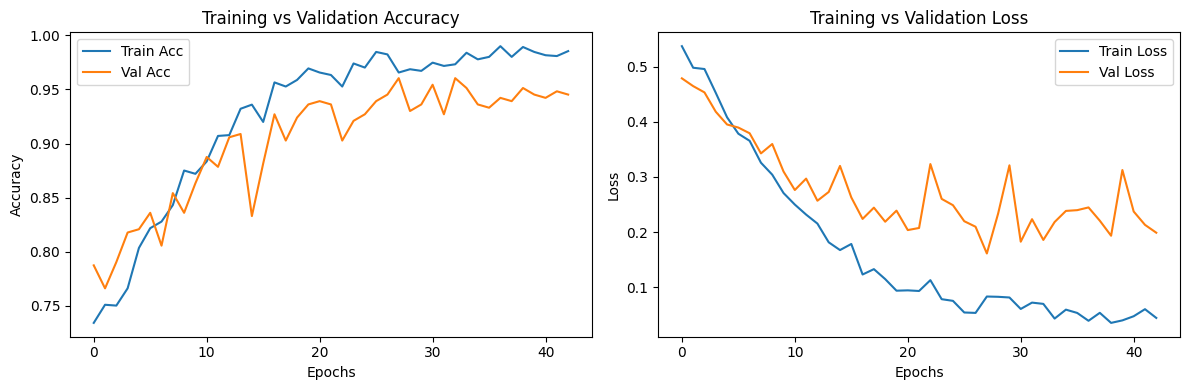


 Classification Report:
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
              precision    recall  f1-score   support

          TC    0.96000   0.97462   0.96725       197
          TS    0.96124   0.93939   0.95019       132

    accuracy                        0.96049       329
   macro avg    0.96062   0.95701   0.95872       329
weighted avg    0.96050   0.96049   0.96041       329



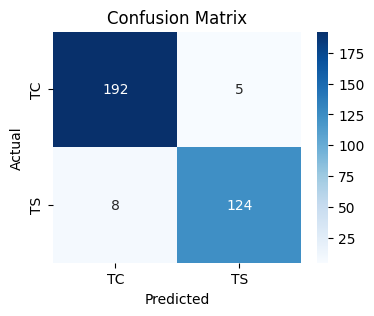

In [ ]:
# Step 3: DNN Classifier
classifier = Sequential([
    Dense(256, activation='relu', input_shape=(X.shape[1],)),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary output: TC vs TS
])

classifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True)

history = classifier.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Step 4: Plot Accuracy and Loss
plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Step 5: Evaluation
print("\n Classification Report:")
y_pred = (classifier.predict(X_test) > 0.5).astype("int32")
print(classification_report(y_test, y_pred, target_names=['TC', 'TS'], digits=5))

# Step 6: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['TC', 'TS'], yticklabels=['TC', 'TS'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


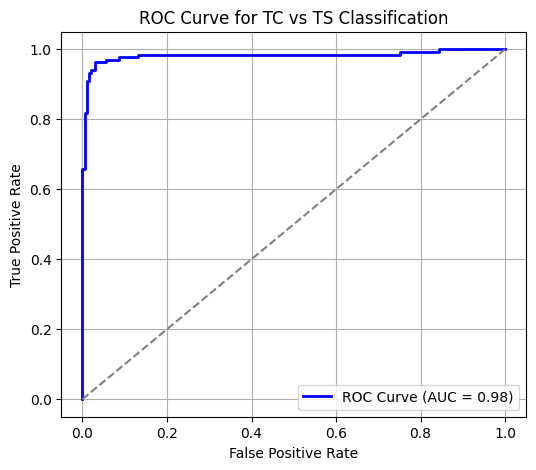

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Predict probabilities (not hard labels)
y_pred_probs = classifier.predict(X_test)

# ROC Curve and AUC Score
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = roc_auc_score(y_test, y_pred_probs)

# Plot the ROC Curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for TC vs TS Classification')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


#PCA DNN


 Building and training classification model with reduced features...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.6700 - loss: 0.6026 - val_accuracy: 0.8024 - val_loss: 0.4393
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8128 - loss: 0.4146 - val_accuracy: 0.8511 - val_loss: 0.3584
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8963 - loss: 0.2619 - val_accuracy: 0.8875 - val_loss: 0.2730
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9702 - loss: 0.1396 - val_accuracy: 0.9179 - val_loss: 0.2173
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9828 - loss: 0.0795 - val_accuracy: 0.9240 - val_loss: 0.1908
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9940 - loss: 0.0403 - val_accuracy: 0.9514 - val_loss: 0.1467
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9982 - loss: 0.0197 - val_accuracy: 0.9544 - val_loss: 0.1243
Epoch 8/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9987 - loss: 0.0144 - val_accuracy: 0.9544 - 

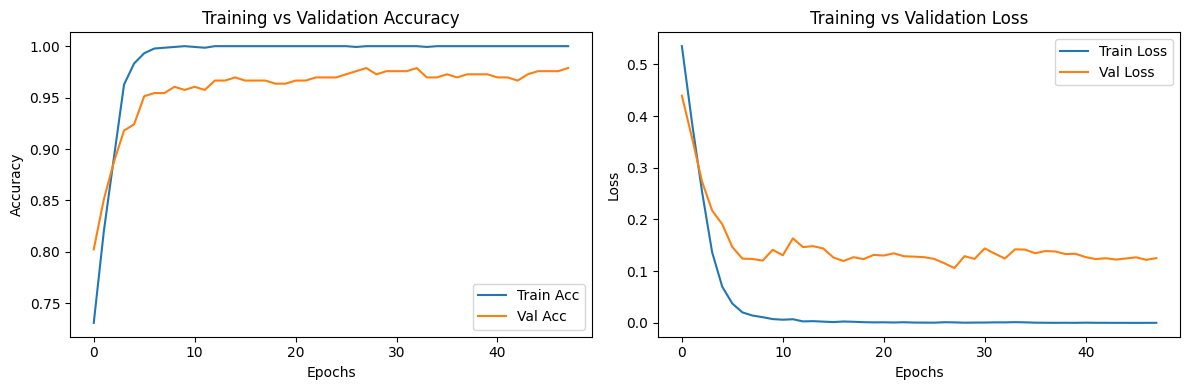


 Classification Report:
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
              precision    recall  f1-score   support

          TC    0.97500   0.98985   0.98237       197
          TS    0.98450   0.96212   0.97318       132

    accuracy                        0.97872       329
   macro avg    0.97975   0.97598   0.97777       329
weighted avg    0.97881   0.97872   0.97868       329



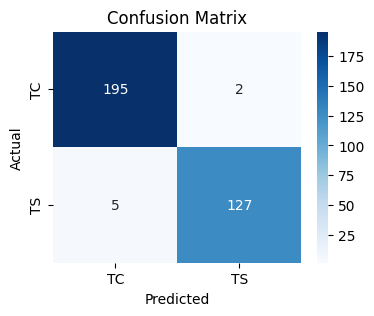

In [ ]:
# Step 3: Build and Train the Classification Model
print("\n Building and training classification model with reduced features...")
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2, stratify=y, random_state=42
)
classifier = Sequential([
    Dense(256, activation='relu', input_shape=(X_reduced.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # For binary classification: TC (0) vs TS (1)
])

classifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True)

history = classifier.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Step 4: Plot Accuracy and Loss
plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Step 5: Evaluation
print("\n Classification Report:")
y_pred = (classifier.predict(X_test) > 0.5).astype("int32")
print(classification_report(y_test, y_pred, target_names=['TC', 'TS'], digits=5))

# Step 6: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['TC', 'TS'], yticklabels=['TC', 'TS'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


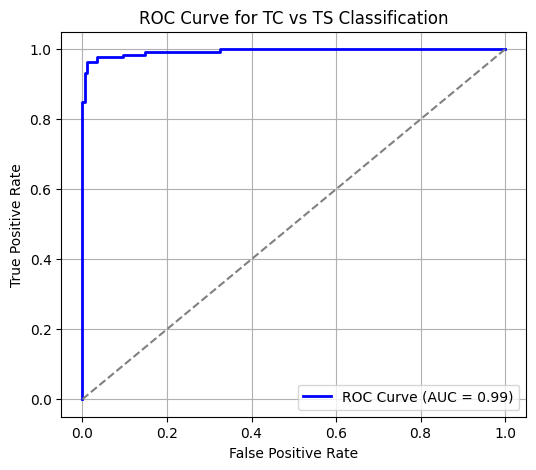

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Predict probabilities (not hard labels)
y_pred_probs = classifier.predict(X_test)

# ROC Curve and AUC Score
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = roc_auc_score(y_test, y_pred_probs)

# Plot the ROC Curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for TC vs TS Classification')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


#PCA on ML


 Model: Random Forest
Accuracy: 0.8480
ROC AUC: 0.9716
Classification Report:
              precision    recall  f1-score   support

          TC       0.80      0.99      0.89       197
          TS       0.98      0.64      0.77       132

    accuracy                           0.85       329
   macro avg       0.89      0.81      0.83       329
weighted avg       0.87      0.85      0.84       329


 Model: Extra Trees
Accuracy: 0.8784
ROC AUC: 0.9788
Classification Report:
              precision    recall  f1-score   support

          TC       0.84      0.99      0.91       197
          TS       0.98      0.71      0.82       132

    accuracy                           0.88       329
   macro avg       0.91      0.85      0.87       329
weighted avg       0.89      0.88      0.87       329


 Model: AdaBoost
Accuracy: 0.8298
ROC AUC: 0.8876
Classification Report:
              precision    recall  f1-score   support

          TC       0.83      0.90      0.86       197
       

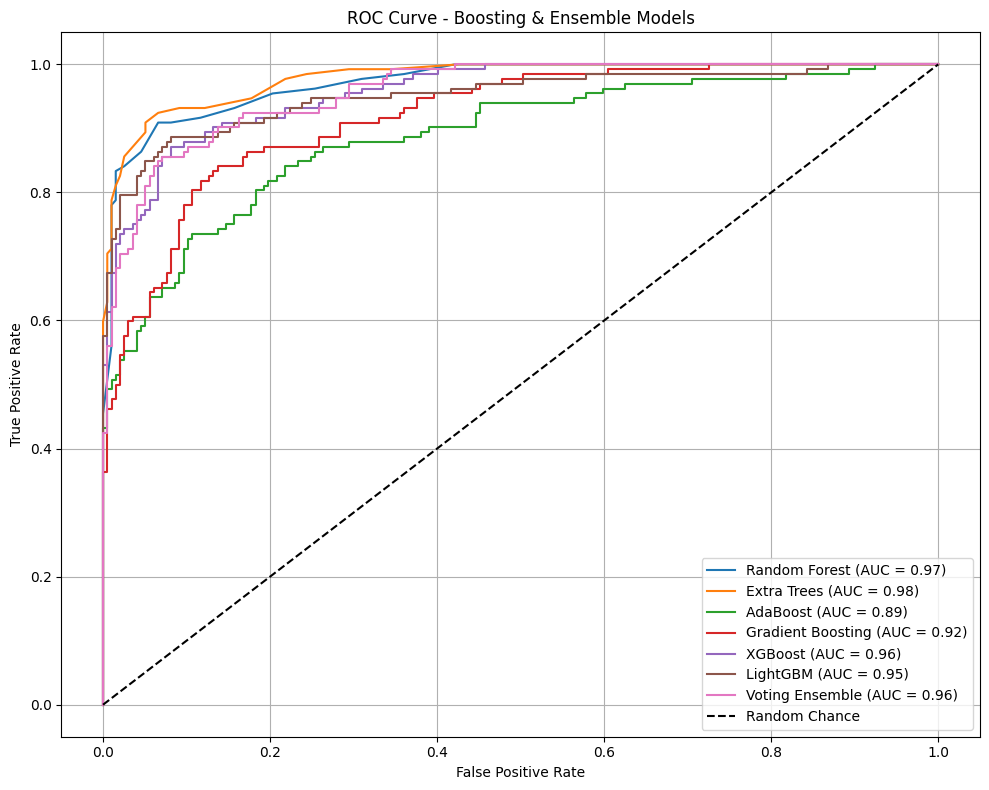

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier,
    GradientBoostingClassifier, ExtraTreesClassifier, VotingClassifier
)
from sklearn.metrics import (
    classification_report, accuracy_score,
    roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# === ASSUME features and labels already loaded as X_features, y_labels ===

# Train/test split
#X_train, X_test, y_train, y_test = train_test_split(X_pca, y_labels, test_size=0.2, random_state=42)

# === MODELS ===
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42),
}

# Add a Voting Classifier (Ensemble)
models["Voting Ensemble"] = VotingClassifier(
    estimators=[
        ('rf', models["Random Forest"]),
        ('gb', models["Gradient Boosting"]),
        ('xgb', models["XGBoost"])
    ],
    voting='soft'
)

# === EVALUATION ===
plt.figure(figsize=(10, 8))
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=["TC", "TS"])
    auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    # Print performance
    print(f"\n Model: {name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"ROC AUC: {auc:.4f}")
    print("Classification Report:")
    print(report)

    # Plot ROC
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

# === ROC Curve Final Plot ===
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Boosting & Ensemble Models')
plt.legend(loc='lower right')
plt.grid()
plt.tight_layout()
plt.show()


## NO PCA ML



 Model: Random Forest
Accuracy: 0.8663
ROC AUC: 0.9359
Classification Report:
              precision    recall  f1-score   support

          TC       0.84      0.95      0.90       197
          TS       0.92      0.73      0.82       132

    accuracy                           0.87       329
   macro avg       0.88      0.84      0.86       329
weighted avg       0.87      0.87      0.86       329


 Model: Extra Trees
Accuracy: 0.9149
ROC AUC: 0.9673
Classification Report:
              precision    recall  f1-score   support

          TC       0.90      0.97      0.93       197
          TS       0.95      0.83      0.89       132

    accuracy                           0.91       329
   macro avg       0.92      0.90      0.91       329
weighted avg       0.92      0.91      0.91       329


 Model: AdaBoost
Accuracy: 0.8116
ROC AUC: 0.9000
Classification Report:
              precision    recall  f1-score   support

          TC       0.81      0.89      0.85       197
       

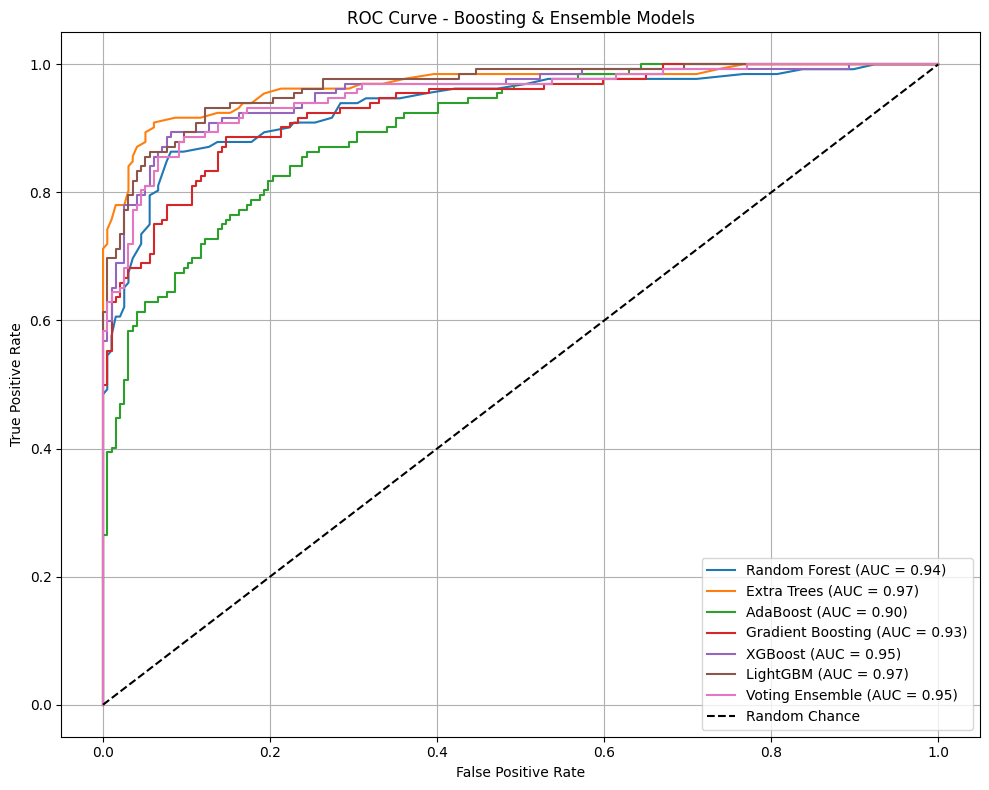

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier,
    GradientBoostingClassifier, ExtraTreesClassifier, VotingClassifier
)
from sklearn.metrics import (
    classification_report, accuracy_score,
    roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier



# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# === MODELS ===
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42),
}

# Add a Voting Classifier (Ensemble)
models["Voting Ensemble"] = VotingClassifier(
    estimators=[
        ('rf', models["Random Forest"]),
        ('gb', models["Gradient Boosting"]),
        ('xgb', models["XGBoost"])
    ],
    voting='soft'
)

# === EVALUATION ===
plt.figure(figsize=(10, 8))
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=["TC", "TS"])
    auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    # Print performance
    print(f"\n Model: {name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"ROC AUC: {auc:.4f}")
    print("Classification Report:")
    print(report)

    # Plot ROC
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

# === ROC Curve Final Plot ===
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Boosting & Ensemble Models')
plt.legend(loc='lower right')
plt.grid()
plt.tight_layout()
plt.show()


## EfficientNetB0

In [ ]:
def load_images(folder, label):
    images, labels = [], []
    for path in glob.glob(os.path.join(folder, '*.jpg')):
        img = load_img(path, target_size=(224, 224))
        img = img_to_array(img)
        img = preprocess_input(img)
        images.append(img)
        labels.append(label)
    return images, labels

# Load from your cropped folders
tc_imgs, tc_labels = load_images('/kaggle/working/Dataset/TC/Cropped', 0)
ts_imgs, ts_labels = load_images('/kaggle/working/Dataset/TS/Cropped', 1)

X = np.array(tc_imgs + ts_imgs)
y = np.array(tc_labels + ts_labels)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)


#EfficeientNet Base

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Input shape
input_shape = (224, 224, 3)

# 1. Load EfficientNetB0 base model (exclude top layers)
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=input_shape
)

# 2. Freeze initial layers (to avoid overfitting small dataset)
for layer in base_model.layers[:150]:
    layer.trainable = False
for layer in base_model.layers[150:]:
    layer.trainable = True

# 3. Add custom classification head
x = GlobalAveragePooling2D()(base_model.output)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)  # For binary classification

# 4. Build final model
model = Model(inputs=base_model.input, outputs=output)

# 5. Learning rate schedule
lr_schedule = ExponentialDecay(
    initial_learning_rate=1e-4,
    decay_steps=1000,
    decay_rate=0.9,
    staircase=True
)

# 6. Compile model
model.compile(
    optimizer=Adam(learning_rate=lr_schedule),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 7. Callbacks
early_stop = EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint("best_efficientnet_model.keras", monitor="val_accuracy", save_best_only=True, verbose=1)

# 8. Train model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, checkpoint],
    verbose=1
)


Epoch 1/100


E0000 00:00:1745220968.667735      96 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1745220968.864499      96 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1745220969.482203      96 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1745220969.689161      96 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1745220970.047174      96 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:0

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5688 - loss: 0.8434
Epoch 1: val_accuracy improved from -inf to 0.63222, saving model to best_efficientnet_model.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 59s 338ms/step - accuracy: 0.5700 - loss: 0.8415 - val_accuracy: 0.6322 - val_loss: 0.6430
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.7223 - loss: 0.6100
Epoch 2: val_accuracy improved from 0.63222 to 0.65350, saving model to best_efficientnet_model.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.7226 - loss: 0.6091 - val_accuracy: 0.6535 - val_loss: 0.6084
Epoch 3/100
40/41 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8006 - loss: 0.4415
Epoch 3: val_accuracy improved from 0.65350 to 0.72340, saving model to best_efficientnet_model.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.7999 - loss: 0.4425 - val_accuracy: 0.7234 - val_loss: 0.5381
Epoch 4/100
40/41 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8282 - loss: 0.3618
Epoch 4: val_ac

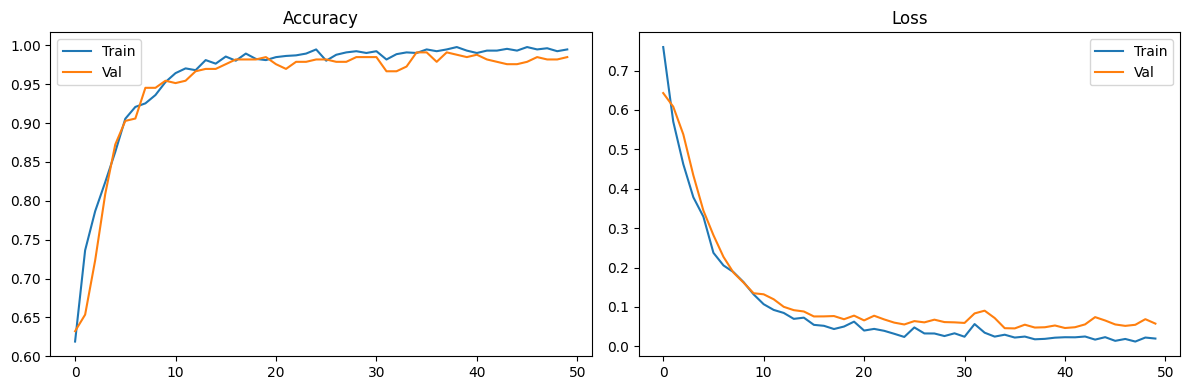

11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 637ms/step
Classification Report:
               precision    recall  f1-score   support

          TC    0.98990   0.99492   0.99241       197
          TS    0.99237   0.98485   0.98859       132

    accuracy                        0.99088       329
   macro avg    0.99113   0.98989   0.99050       329
weighted avg    0.99089   0.99088   0.99088       329



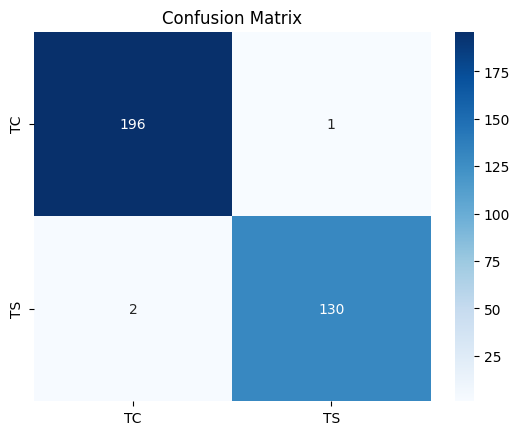

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title("Accuracy"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title("Loss"); plt.legend()
plt.tight_layout()
plt.show()

y_pred = (model.predict(X_test) > 0.5).astype('int32')
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=['TC', 'TS'], digits=5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['TC', 'TS'], yticklabels=['TC', 'TS'])
plt.title("Confusion Matrix")
plt.show()


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


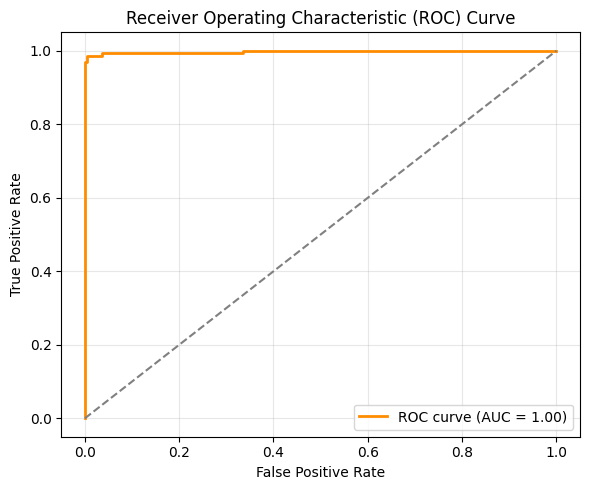

In [ ]:
# Get predicted probabilities
y_pred_prob = model.predict(X_test).ravel()

# Compute ROC metrics
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def display_gradcam_batch(X_data, y_data, model, num_samples=5, last_conv_layer='conv5_block16_2_conv'):
    indices = random.sample(range(len(X_data)), num_samples)

    for idx in indices:
        img = X_data[idx]
        label = y_data[idx]
        img_input = np.expand_dims(img, axis=0)  # Add batch dimension

        # Generate Grad-CAM heatmap
        heatmap = make_gradcam_heatmap(img_input, model, last_conv_layer)

        # Reconstruct original image (if necessary for your preprocessing)
        orig = img.copy()
        orig = orig[..., ::-1]  # Convert from BGR to RGB if needed (if image is in BGR format)
        orig += [123.68, 116.779, 103.939]  # Reverse the DenseNet mean subtraction (RGB order now)
        orig = np.clip(orig, 0, 255).astype('uint8')

        # Resize and overlay heatmap
        heatmap_resized = cv2.resize(heatmap, (orig.shape[1], orig.shape[0]))
        heatmap_vis = np.uint8(255 * heatmap_resized)
        overlay = cv2.applyColorMap(heatmap_vis, cv2.COLORMAP_JET)
        overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)  # Convert to RGB for display
        superimposed = cv2.addWeighted(orig, 0.6, overlay, 0.4, 0)

        # Model prediction
        pred = model.predict(img_input)[0]  # Model prediction (assumes binary classification)

        # Predict class
        pred_class = 'TS' if pred >= 0.5 else 'TC'
        actual_class = 'TS' if label == 1 else 'TC'

        # Plotting
        plt.figure(figsize=(12, 4))
        #plt.suptitle(f"True: {actual_class} | Pred: {pred_class} ({pred:.2f})", fontsize=14)
        plt.suptitle(f"True: {actual_class} | Pred: {pred_class} ({pred[0]:.2f})", fontsize=14)


        plt.subplot(1, 3, 1)
        plt.imshow(orig)
        plt.title("Original")
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.imshow(heatmap_resized, cmap='jet')
        plt.title("Heatmap")
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.imshow(superimposed)
        plt.title("Overlay")
        plt.axis('off')

        plt.tight_layout()
        plt.show()


In [ ]:
import numpy as np
import tensorflow as tf

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0].numpy()
    pooled_grads = pooled_grads.numpy()

    for i in range(pooled_grads.shape[-1]):
        conv_outputs[:, :, i] *= pooled_grads[i]

    heatmap = np.mean(conv_outputs, axis=-1)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= (np.max(heatmap) + 1e-8)

    return heatmap


In [ ]:
import matplotlib.pyplot as plt
import cv2

def display_gradcam(img_array, original_img, model, last_conv_layer_name='conv5_block16_2_conv', alpha=0.4):
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

    # Resize heatmap to match original image
    heatmap_resized = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)

    # Overlay heatmap on original image
    superimposed_img = heatmap_colored * alpha + original_img

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(original_img.astype('uint8'))
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(np.uint8(superimposed_img))
    plt.title('Grad-CAM')
    plt.axis('off')

    plt.tight_layout()
    plt.show()


In [ ]:
import numpy as np
import tensorflow as tf
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name='top_conv'):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0].numpy()
    pooled_grads = pooled_grads.numpy()

    for i in range(pooled_grads.shape[-1]):
        conv_outputs[:, :, i] *= pooled_grads[i]

    heatmap = np.mean(conv_outputs, axis=-1)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= (np.max(heatmap) + 1e-8)
    return heatmap



In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.efficientnet import preprocess_input

def show_gradcam_on_image(img_path, model, last_conv_layer='top_conv'):
    # Load image
    img = load_img(img_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_processed = preprocess_input(np.expand_dims(img_array, axis=0))

    # Get heatmap
    heatmap = make_gradcam_heatmap(img_processed, model, last_conv_layer)

    # Resize heatmap to original image
    heatmap_resized = cv2.resize(heatmap, (img_array.shape[1], img_array.shape[0]))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)

    # Superimpose
    superimposed_img = heatmap_colored * 0.4 + img_array

    # Plot
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_array.astype('uint8'))
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(np.uint8(superimposed_img))
    plt.title('Grad-CAM')
    plt.axis('off')
    plt.tight_layout()
    plt.show()


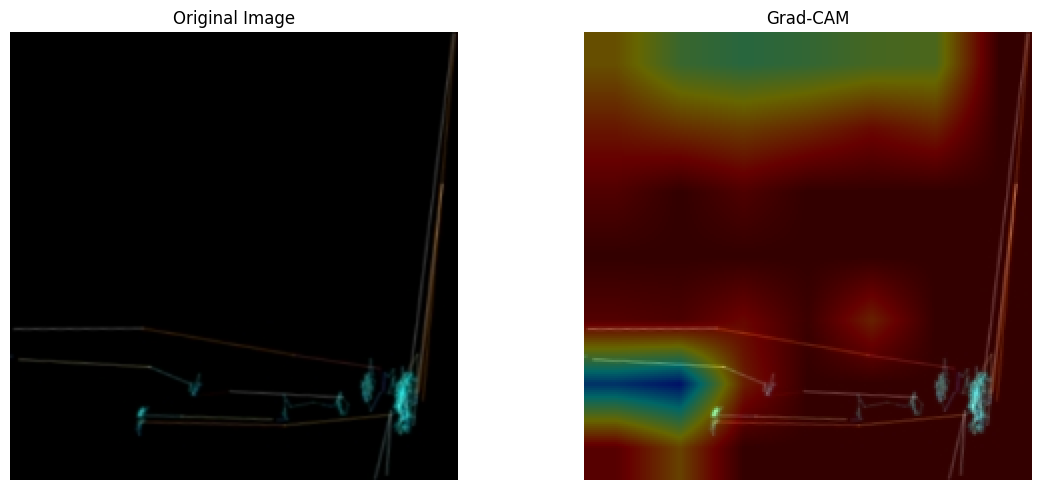

In [ ]:
sample_image = '/kaggle/working/Dataset/TC/Cropped/TC001_39_aug_0_3110.jpg'  # Replace with your path
show_gradcam_on_image(sample_image, model)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.efficientnet import preprocess_input

# Step 1: Generate Grad-CAM heatmap
def make_gradcam_heatmap(img_array, model, last_conv_layer_name='top_conv'):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0].numpy()
    pooled_grads = pooled_grads.numpy()

    for i in range(pooled_grads.shape[-1]):
        conv_outputs[:, :, i] *= pooled_grads[i]

    heatmap = np.mean(conv_outputs, axis=-1)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= (np.max(heatmap) + 1e-8)
    return heatmap

# Step 2: Overlay heatmap and display
def show_gradcam_on_image(img_path, model, last_conv_layer='top_conv'):
    # Load and preprocess image
    img = load_img(img_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_processed = preprocess_input(np.expand_dims(img_array, axis=0))

    # Grad-CAM
    heatmap = make_gradcam_heatmap(img_processed, model, last_conv_layer)

    # Resize heatmap
    heatmap_resized = cv2.resize(heatmap, (img_array.shape[1], img_array.shape[0]))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)

    # Superimpose on original
    superimposed_img = heatmap_colored * 0.4 + img_array

    # Plot original, heatmap, and superimposed
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img_array.astype('uint8'))
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap, cmap='jet')
    plt.title("Grad-CAM Heatmap")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(np.uint8(superimposed_img))
    plt.title("Superimposed Image")
    plt.axis('off')

    plt.tight_layout()
    plt.show()


In [ ]:
import random
import glob
import os

def show_random_gradcam_images(model, category_dirs, last_conv_layer='top_conv', num_images=5):
    # Collect all image paths from all category folders
    all_images = []
    for folder in category_dirs.values():
        all_images.extend(glob.glob(os.path.join(folder, '*.jpg')))

    # Select random 5 images
    selected_images = random.sample(all_images, min(num_images, len(all_images)))

    # Show Grad-CAM for each image
    for img_path in selected_images:
        print(f"\n🖼️ Image: {os.path.basename(img_path)}")
        show_gradcam_on_image(img_path, model, last_conv_layer=last_conv_layer)



🖼️ Image: TS169_24_aug_0_8282.jpg


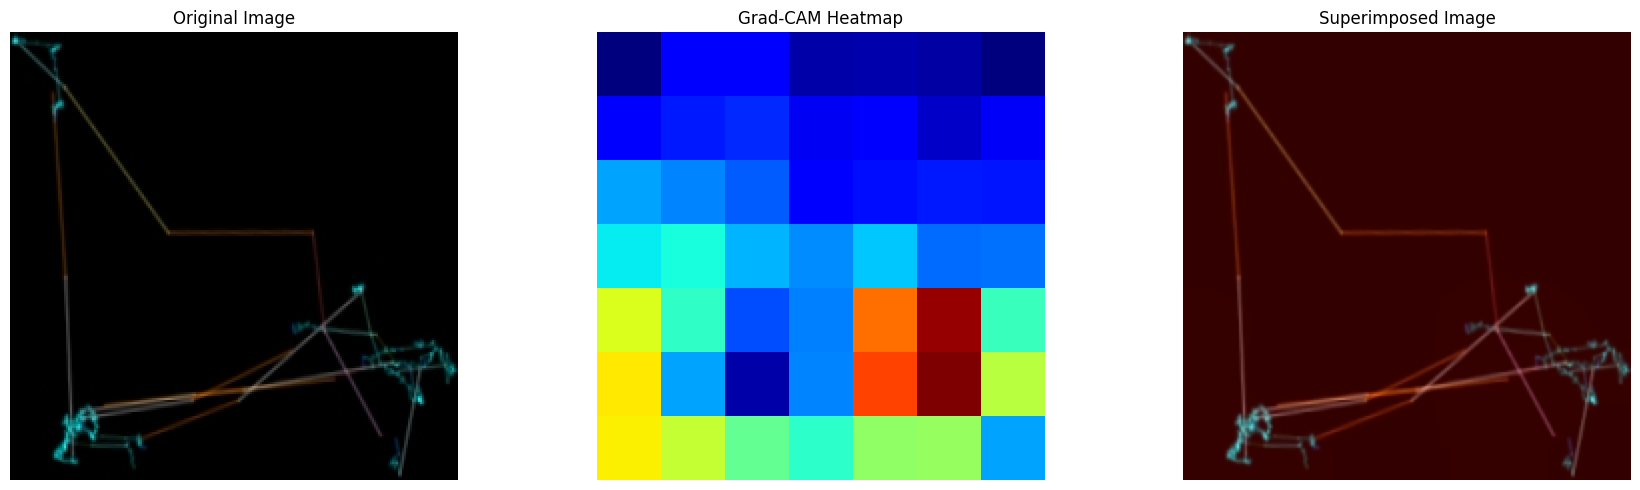


🖼️ Image: TC090_47_aug_0_4512.jpg


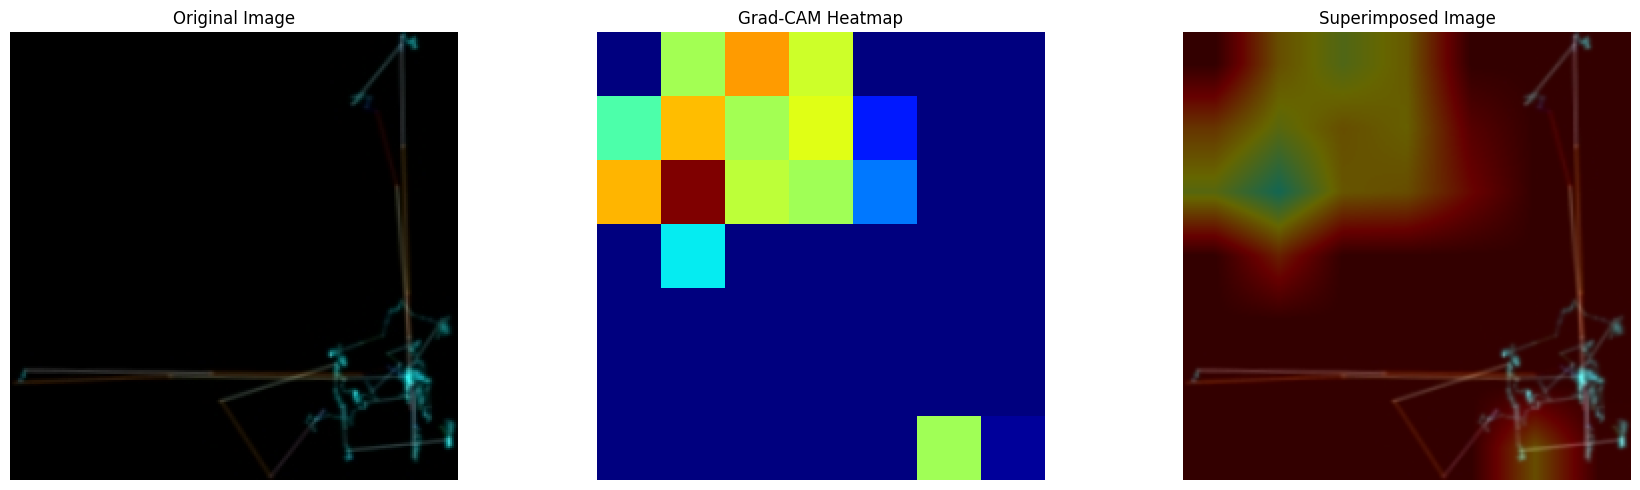


🖼️ Image: TC006_33_aug_0_8690.jpg


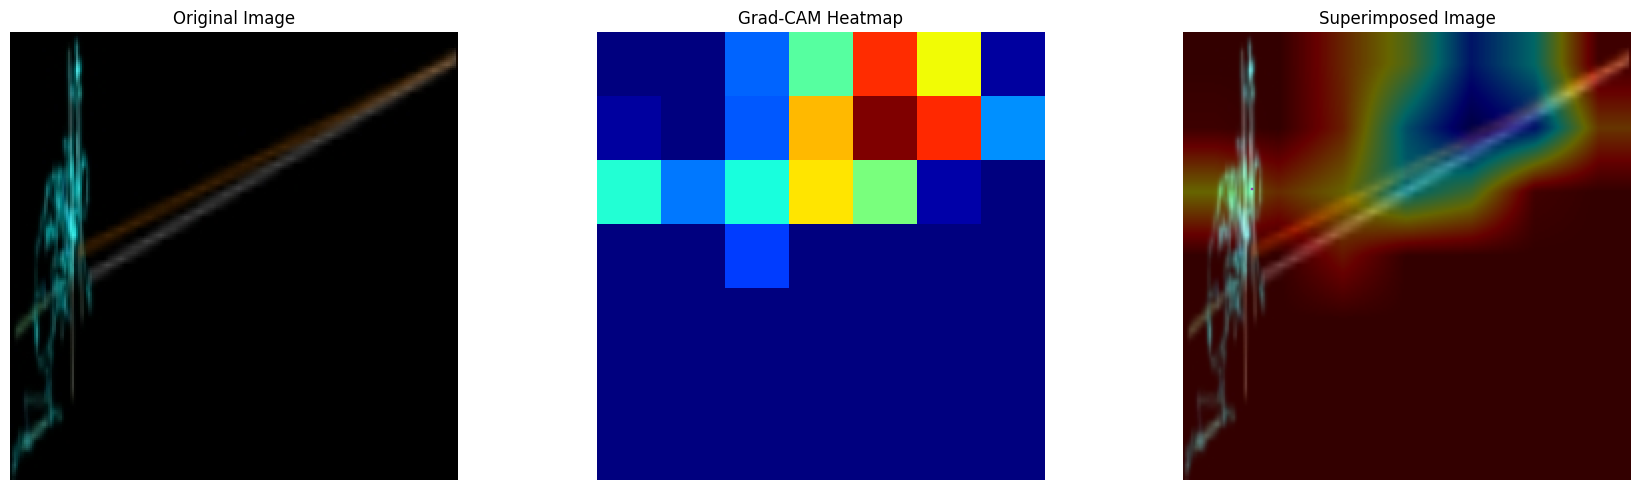


🖼️ Image: TS235_12_aug_0_8288.jpg


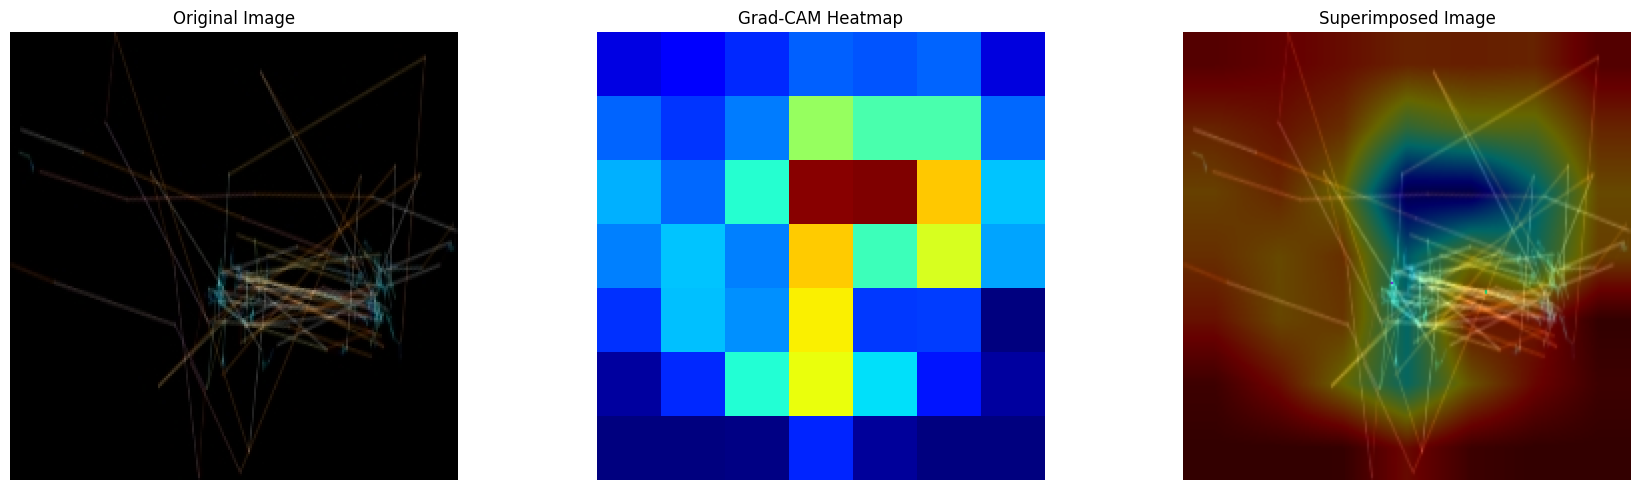


🖼️ Image: TS191_01_aug_0_9037.jpg


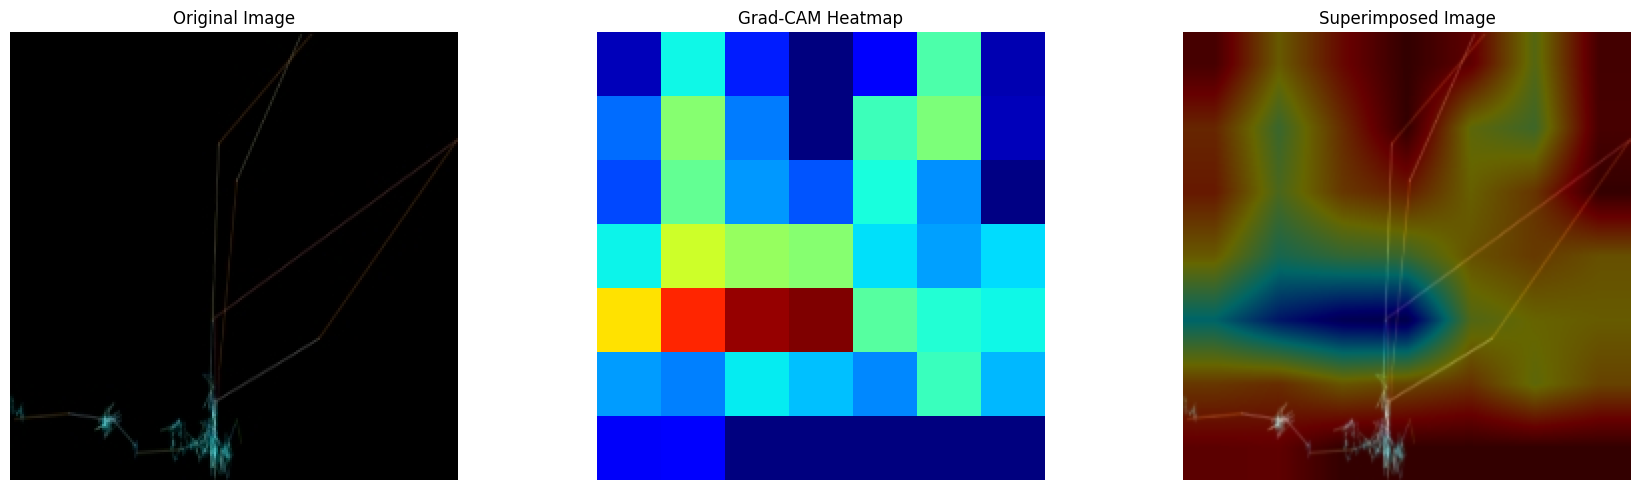

In [ ]:
# Define your folder structure
cropped_dirs = {
    'TC': '/kaggle/working/Dataset/TC/Cropped',
    'TS': '/kaggle/working/Dataset/TS/Cropped'
}

# Call the function
show_random_gradcam_images(model, cropped_dirs, last_conv_layer='top_conv', num_images=5)


In [ ]:
def show_gradcam_on_image(img_path, model, last_conv_layer='top_conv', alpha=0.4, class_names={0: 'TC', 1: 'TS'}):
    import cv2

    # Load and preprocess image
    img = load_img(img_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_processed = preprocess_input(np.expand_dims(img_array, axis=0))

    # Prediction
    pred_prob = model.predict(img_processed)[0][0]
    pred_class = int(pred_prob >= 0.5)  # Binary classification
    pred_label = class_names[pred_class]
    pred_confidence = f"{pred_prob:.4f}"

    # Grad-CAM heatmap
    heatmap = make_gradcam_heatmap(img_processed, model, last_conv_layer)
    heatmap_resized = cv2.resize(heatmap, (img_array.shape[1], img_array.shape[0]), interpolation=cv2.INTER_CUBIC)
    heatmap_resized = np.clip(heatmap_resized, 0, 1)
    heatmap_rgb = np.uint8(255 * plt.cm.jet(heatmap_resized)[:, :, :3])
    superimposed_img = cv2.addWeighted(img_array.astype('uint8'), 1 - alpha, heatmap_rgb, alpha, 0)

    # Print results
    print(f"\n Image: {os.path.basename(img_path)}")
    print(f" Predicted: {pred_label} (probability: {pred_confidence})")

    # Plot
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img_array.astype('uint8'))
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_resized, cmap='jet')
    plt.title("Grad-CAM Heatmap")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(superimposed_img)
    plt.title(f"Overlayed: {pred_label} ({pred_confidence})")
    plt.axis('off')

    plt.tight_layout()
    plt.show()



🖼️ Image: TC025_52_aug_0_2000.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

 Image: TC025_52_aug_0_2000.jpg
 Predicted: TC (probability: 0.0007)


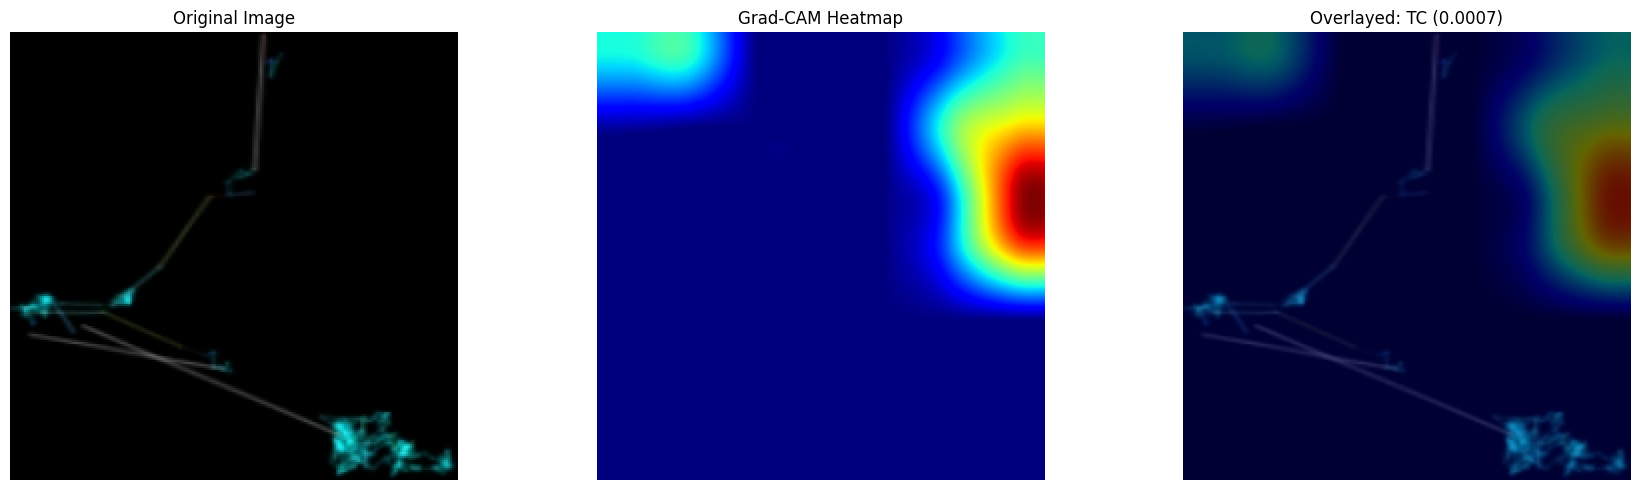


🖼️ Image: TS071_14_aug_0_5047.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

 Image: TS071_14_aug_0_5047.jpg
 Predicted: TS (probability: 1.0000)


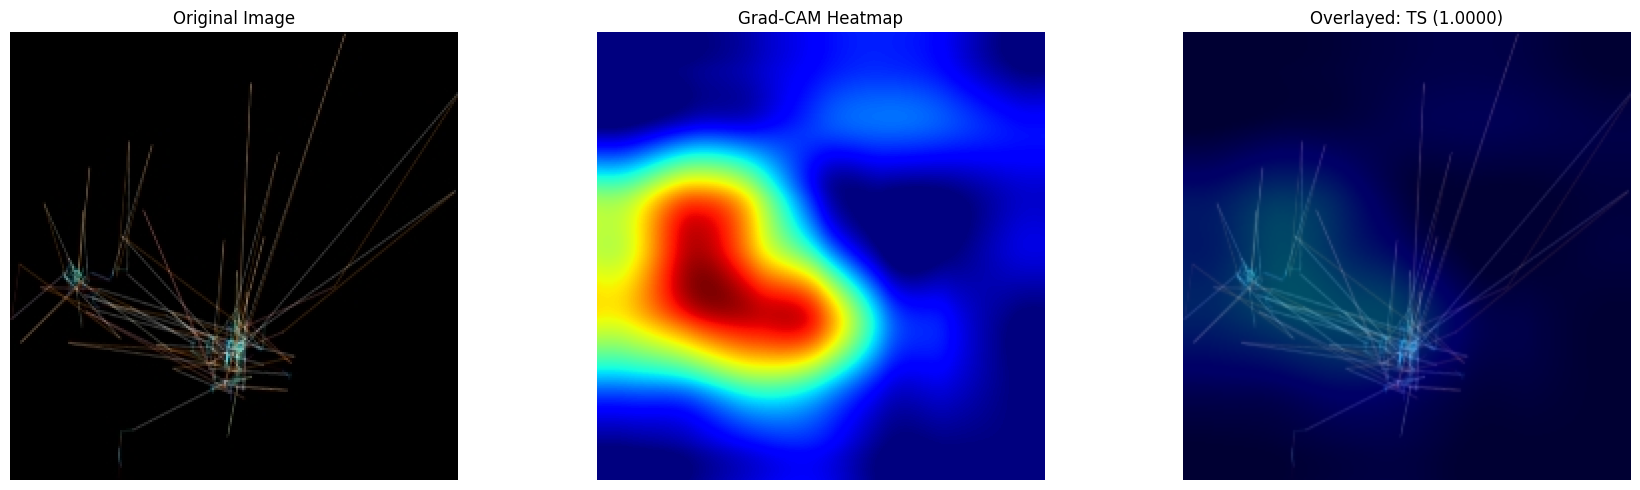


🖼️ Image: TS014_17_aug_0_378.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

 Image: TS014_17_aug_0_378.jpg
 Predicted: TS (probability: 1.0000)


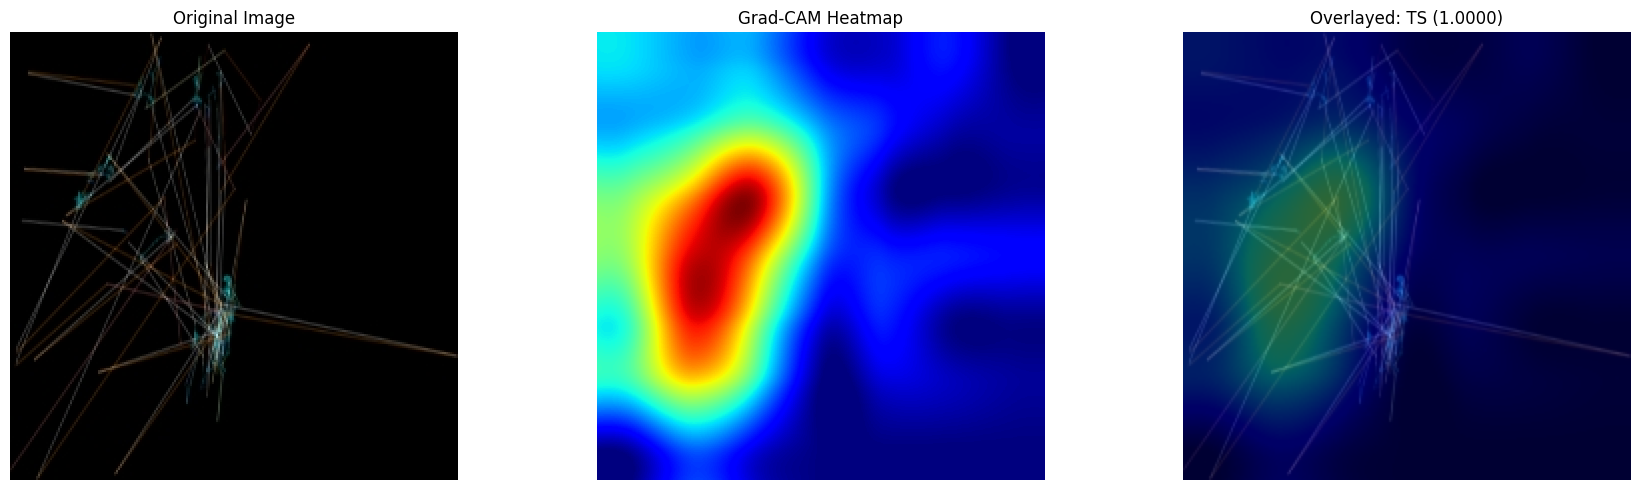


🖼️ Image: TC022_52_aug_0_8499.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

 Image: TC022_52_aug_0_8499.jpg
 Predicted: TC (probability: 0.0004)


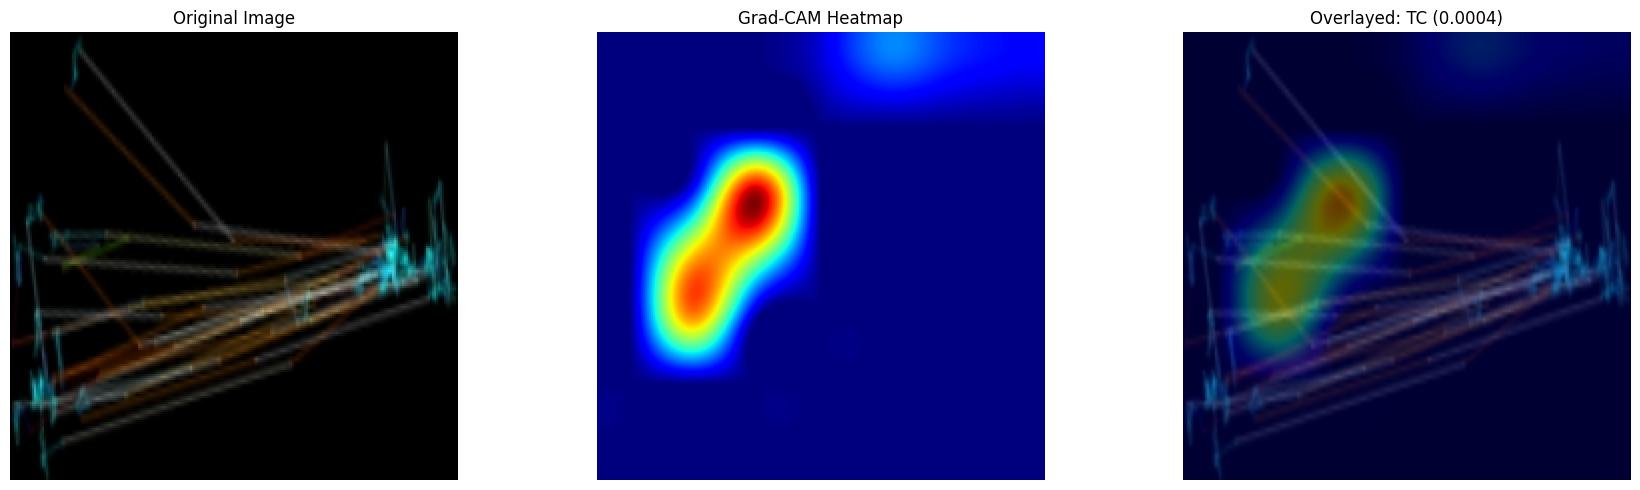


🖼️ Image: TC178_30_aug_0_7783.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

 Image: TC178_30_aug_0_7783.jpg
 Predicted: TC (probability: 0.0063)


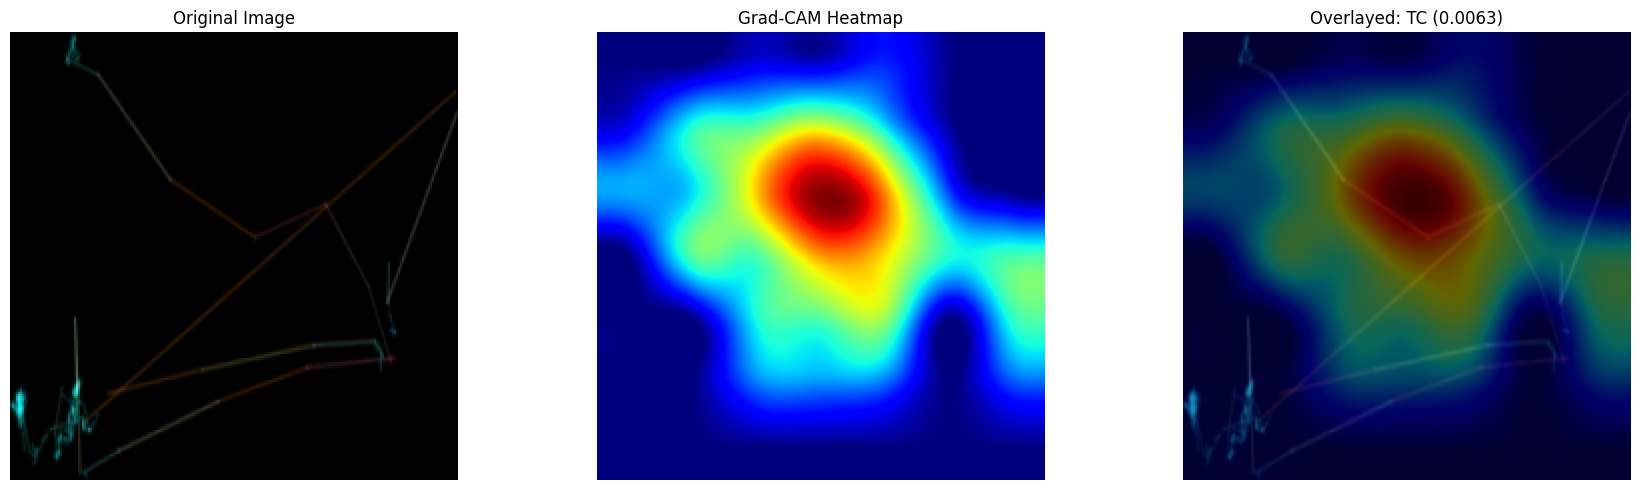

In [ ]:
# Define your folder structure
cropped_dirs = {
    'TC': '/kaggle/working/Dataset/TC/Cropped',
    'TS': '/kaggle/working/Dataset/TS/Cropped'
}

# Call the function
show_random_gradcam_images(model, cropped_dirs, last_conv_layer='top_conv', num_images=5)